https://www.kaggle.com/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset

# **Conjunto de dados sobre a adoção global de IA e seu impacto na força de trabalho**

**Adoção de IA pela empresa, impacto na força de trabalho, produtividade e métricas de governança**

# Conjunto de dados sobre a adoção global de IA e seu impacto na força de trabalho

A adoção da Inteligência Artificial está transformando rapidamente a forma como as organizações operam, automatizam tarefas e remodelam sua força de trabalho. Compreender a relação entre a adoção da IA, a produtividade, a governança e as mudanças na força de trabalho é fundamental para pesquisadores, analistas e formuladores de políticas.

Este conjunto de dados fornece uma visão estruturada de como empresas de diferentes setores e países adotam tecnologias de IA e como essas decisões afetam a produtividade, a dinâmica da força de trabalho e os resultados operacionais.

O conjunto de dados captura indicadores em nível empresarial, incluindo estágio de adoção de IA, investimentos em IA, taxas de automação, mudanças na força de trabalho, práticas de governança e métricas de desempenho de negócios. Também inclui indicadores macroeconômicos de países que influenciam a transformação digital e os padrões de adoção de IA.

O conjunto de dados foi construído agregando padrões observados em relatórios globais de adoção de tecnologia, estudos de transformação digital, publicações sobre análise da força de trabalho e estruturas de governança de IA. Características da empresa, comportamento de adoção, impacto na força de trabalho, mudanças na produtividade e indicadores de inovação foram modelados para refletir o comportamento organizacional realista em diferentes setores e regiões.

A distribuição de funções, os níveis de investimento, as taxas de automação e os ajustes na força de trabalho seguem distribuições estatísticas estruturadas, concebidas para se assemelharem a conjuntos de dados analíticos empresariais do mundo real. Indicadores a nível nacional, como a maturidade digital, a penetração da internet e a intensidade da pesquisa em IA, foram modelados para refletir os ecossistemas tecnológicos globais.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_country = pd.read_csv('country_ai_index.csv')
df_industry = pd.read_csv('ai_industry_summary.csv')
df_company = pd.read_csv('ai_company_adoption.csv')

# EAD

In [2]:
#Visualizando as primeiras linhas do dataset principal (empresas)
print(df_company.head())

   response_id  company_id  survey_year quarter country  region   industry  \
0            1  COMP-00001         2023      Q1   Italy  Europe  Education   
1            2  COMP-00001         2023      Q2   Italy  Europe  Education   
2            3  COMP-00001         2023      Q3   Italy  Europe  Education   
3            4  COMP-00001         2023      Q4   Italy  Europe  Education   
4            5  COMP-00001         2024      Q1   Italy  Europe  Education   

  company_size  num_employees  annual_revenue_usd_millions  ...  \
0      Startup             57                        48.31  ...   
1      Startup             57                        48.31  ...   
2      Startup             57                        48.31  ...   
3      Startup             57                        48.31  ...   
4      Startup             57                        48.31  ...   

   productivity_change_percent  jobs_displaced jobs_created  \
0                         2.65               1            1   
1 

In [3]:
#Limpeza e Cruzamento de Dados (Merge)
#Unindo os dados das empresas com os índices dos países
#Usar 'country' como chave de ligação
df_merged = pd.merge(df_company, df_country, on='country', how='left', suffixes=('', '_country_stats'))

#Verificando se há valores nulos após o merge
print(df_merged.isnull().sum())

response_id                    0
company_id                     0
survey_year                    0
quarter                        0
country                        0
region                         0
industry                       0
company_size                   0
num_employees                  0
annual_revenue_usd_millions    0
company_founding_year          0
company_age                    0
company_age_group              0
ai_adoption_rate               0
ai_adoption_stage              0
years_using_ai                 0
ai_primary_tool                0
num_ai_tools_used              0
ai_use_case                    0
ai_projects_active             0
ai_training_hours              0
ai_budget_percentage           0
ai_maturity_score              0
ai_failure_rate                0
ai_investment_per_employee     0
regulatory_compliance_score    0
data_privacy_level             0
ai_ethics_committee            0
ai_risk_management_score       0
remote_work_percentage         0
employee_s

C:\Users\Usuário\AppData\Local\Temp\ipykernel_8884\640989745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_merged, x='region', y='ai_adoption_rate', estimator='mean', palette='Set2')


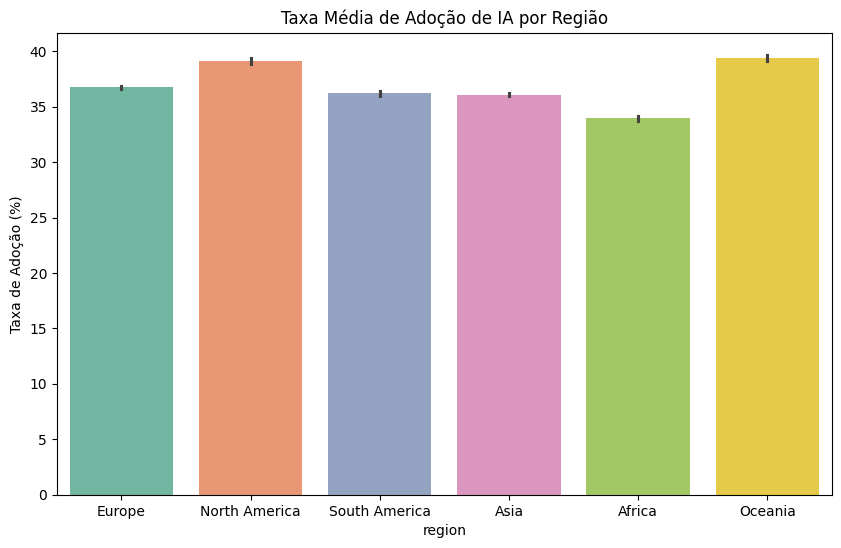

In [4]:
#Análise de Adoção de IA por Região
plt.figure(figsize=(10, 6))
sns.barplot(data=df_merged, x='region', y='ai_adoption_rate', estimator='mean', palette='Set2')
plt.title('Taxa Média de Adoção de IA por Região')
plt.ylabel('Taxa de Adoção (%)')
plt.show()

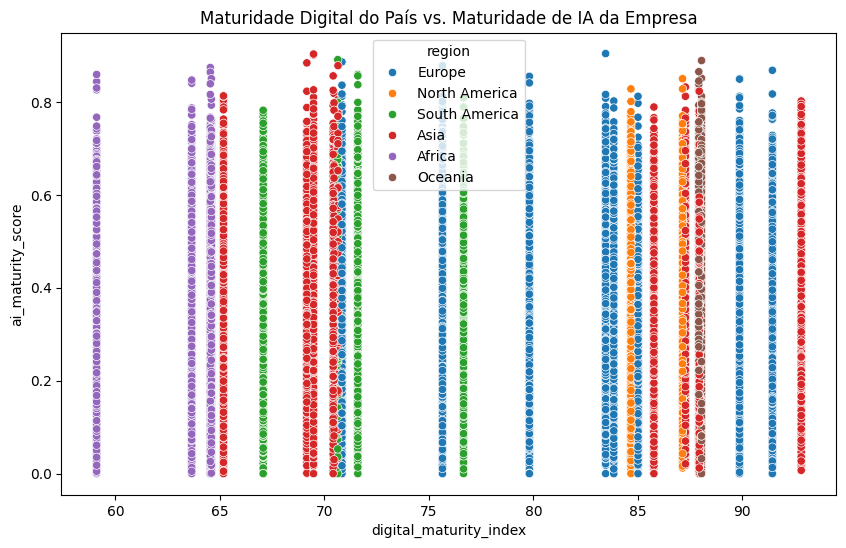

In [5]:
#Relação: Investimento vs. Maturidade Digital
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x='digital_maturity_index', y='ai_maturity_score', hue='region')
plt.title('Maturidade Digital do País vs. Maturidade de IA da Empresa')
plt.show()

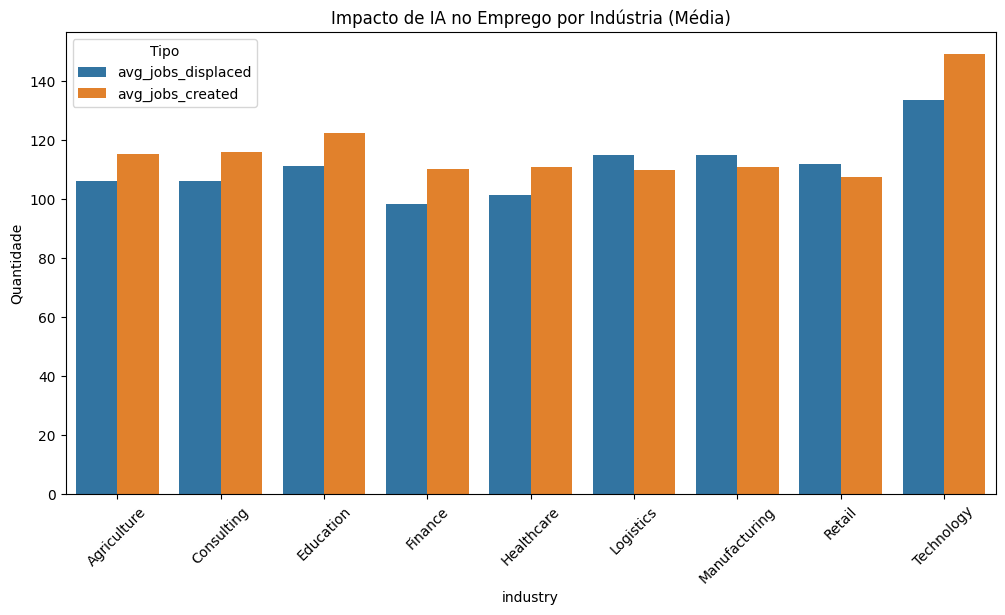

In [6]:
#Impacto no Emprego por Indústria
#Preparando os dados de indústria
df_industry_melted = df_industry.melt(id_vars='industry', 
                                      value_vars=['avg_jobs_displaced', 'avg_jobs_created'],
                                      var_name='Tipo', value_name='Quantidade')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_industry_melted, x='industry', y='Quantidade', hue='Tipo')
plt.xticks(rotation=45)
plt.title('Impacto de IA no Emprego por Indústria (Média)')
plt.show()

# Visualização de Dados

In [7]:
#Merge 1: Empresa + Dados do País
#Unir pela coluna 'country'
df_full = pd.merge(df_company, df_country, on='country', how='left', suffixes=('', '_country'))

#Merge 2: Resultado anterior + Médias da Indústria
#Unir pela coluna 'industry'
df_full = pd.merge(df_full, df_industry, on='industry', how='left', suffixes=('', '_ind_avg'))

print("Base integrada pronta com", df_full.shape[1], "colunas.")

Base integrada pronta com 57 colunas.


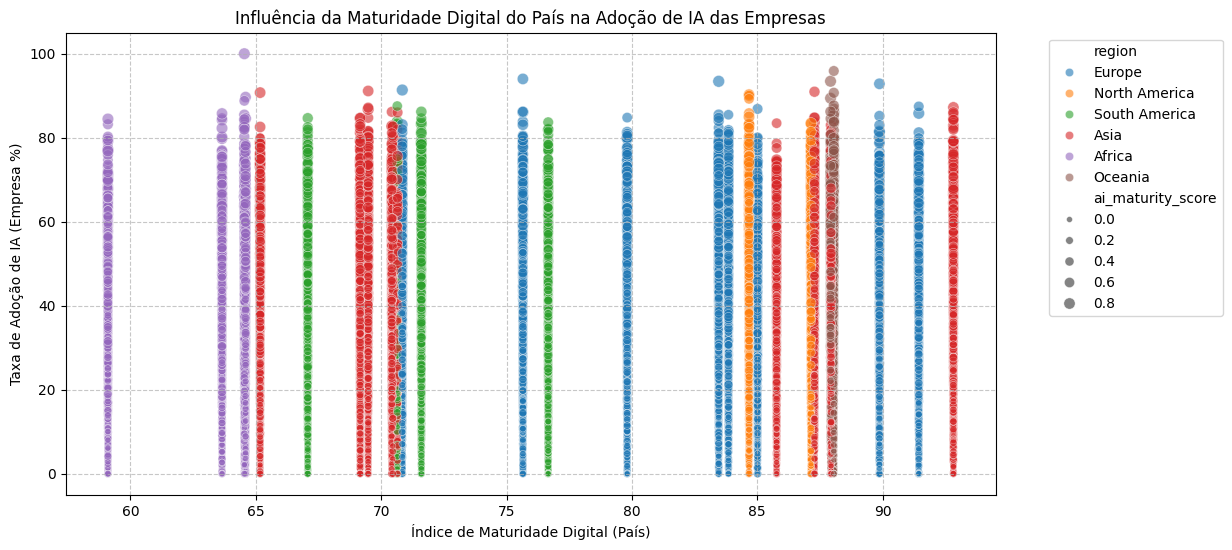

In [8]:
#Visualização: Maturidade Digital vs. Adoção de IA
#Países com infraestrutura digital forte (Internet/Políticas) realmente têm empresas que adotam IA mais rápido?
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_full, x='digital_maturity_index', y='ai_adoption_rate', 
                hue='region', alpha=0.6, size='ai_maturity_score')

plt.title('Influência da Maturidade Digital do País na Adoção de IA das Empresas')
plt.xlabel('Índice de Maturidade Digital (País)')
plt.ylabel('Taxa de Adoção de IA (Empresa %)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

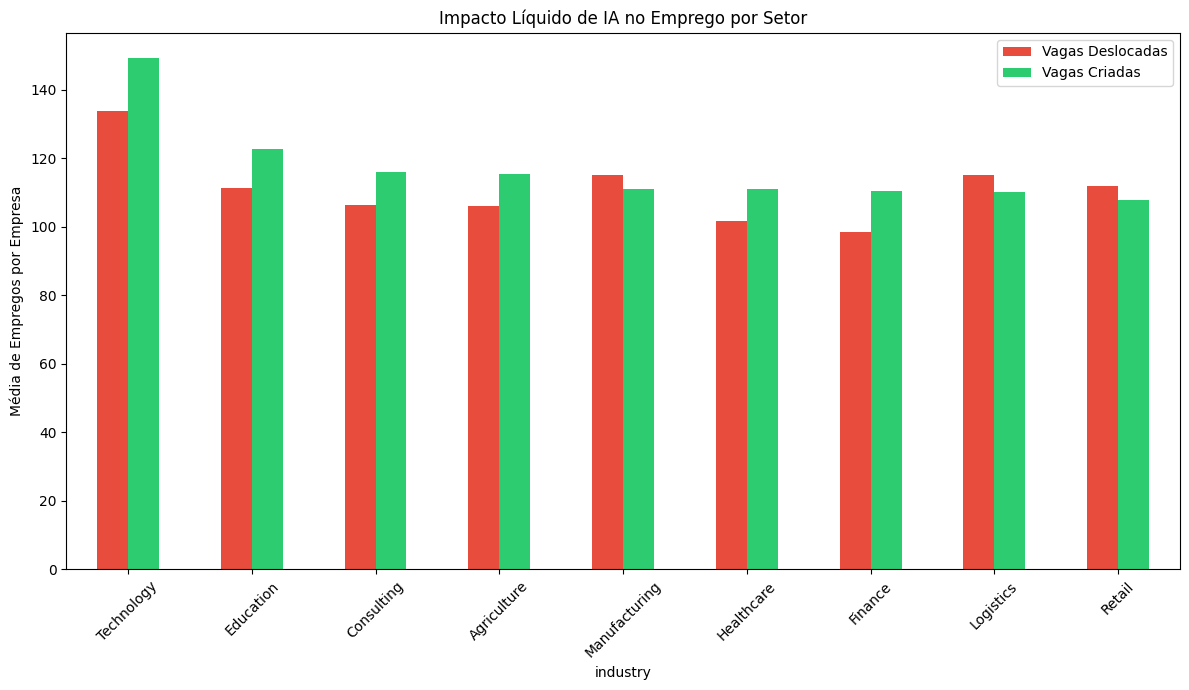

In [9]:
#Equilíbrio de Empregos por Setor
#Ordenando as indústrias que mais criam empregos
top_industries = df_industry.sort_values('avg_jobs_created', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
top_industries.plot(x='industry', y=['avg_jobs_displaced', 'avg_jobs_created'], 
                    kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])

plt.title('Impacto Líquido de IA no Emprego por Setor')
plt.ylabel('Média de Empregos por Empresa')
plt.xticks(rotation=45)
plt.legend(['Vagas Deslocadas', 'Vagas Criadas'])
plt.tight_layout()
plt.show()

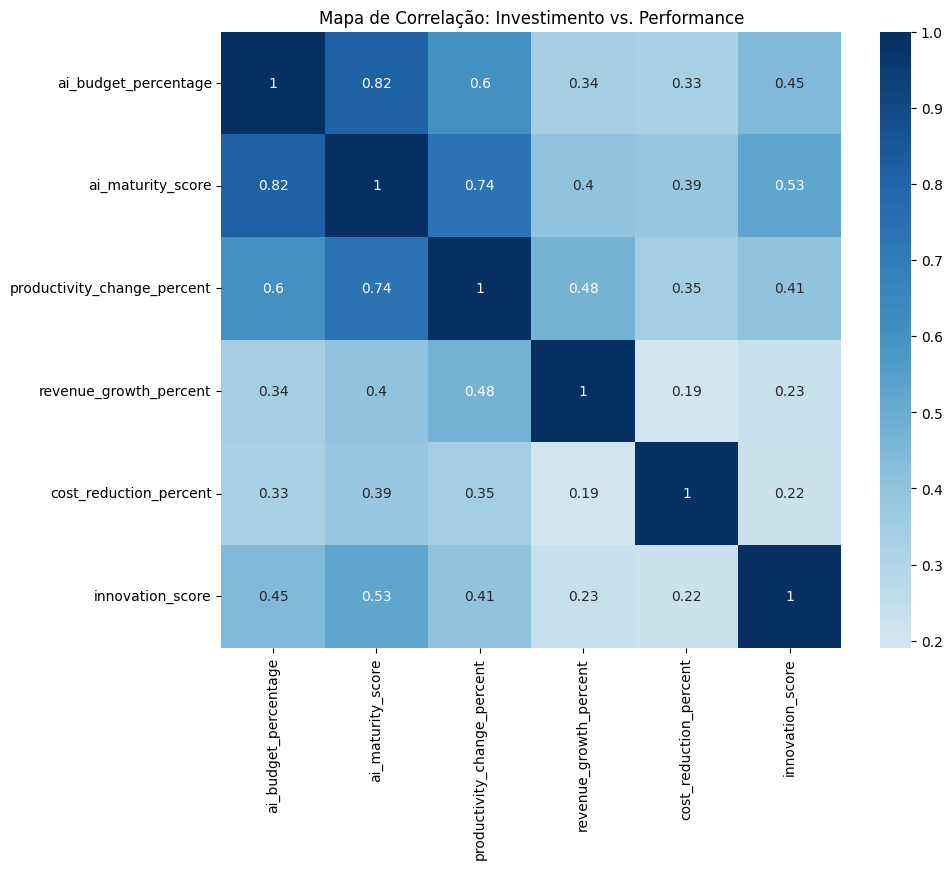

In [10]:
#Análise de Correlação (Heatmap)
#Selecionando colunas numéricas relevantes para o mapa de calor
cols_to_corr = ['ai_budget_percentage', 'ai_maturity_score', 'productivity_change_percent', 
                'revenue_growth_percent', 'cost_reduction_percent', 'innovation_score']

corr_matrix = df_full[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0)
plt.title('Mapa de Correlação: Investimento vs. Performance')
plt.show()

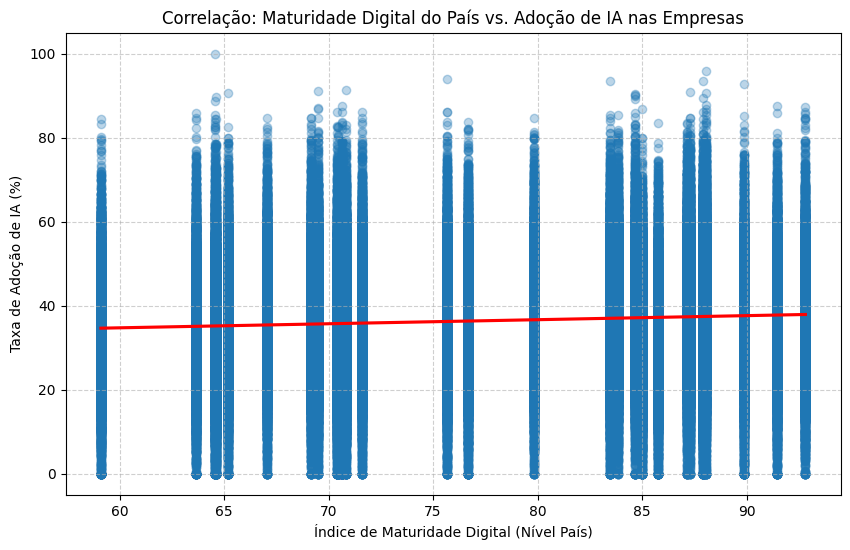

In [11]:
#Cruzamento de dados (Empresas + Países)
df_empresa_pais = pd.merge(df_company, df_country, on='country')

plt.figure(figsize=(10, 6))
sns.regplot(data=df_empresa_pais, x='digital_maturity_index', y='ai_adoption_rate', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Correlação: Maturidade Digital do País vs. Adoção de IA nas Empresas')
plt.xlabel('Índice de Maturidade Digital (Nível País)')
plt.ylabel('Taxa de Adoção de IA (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

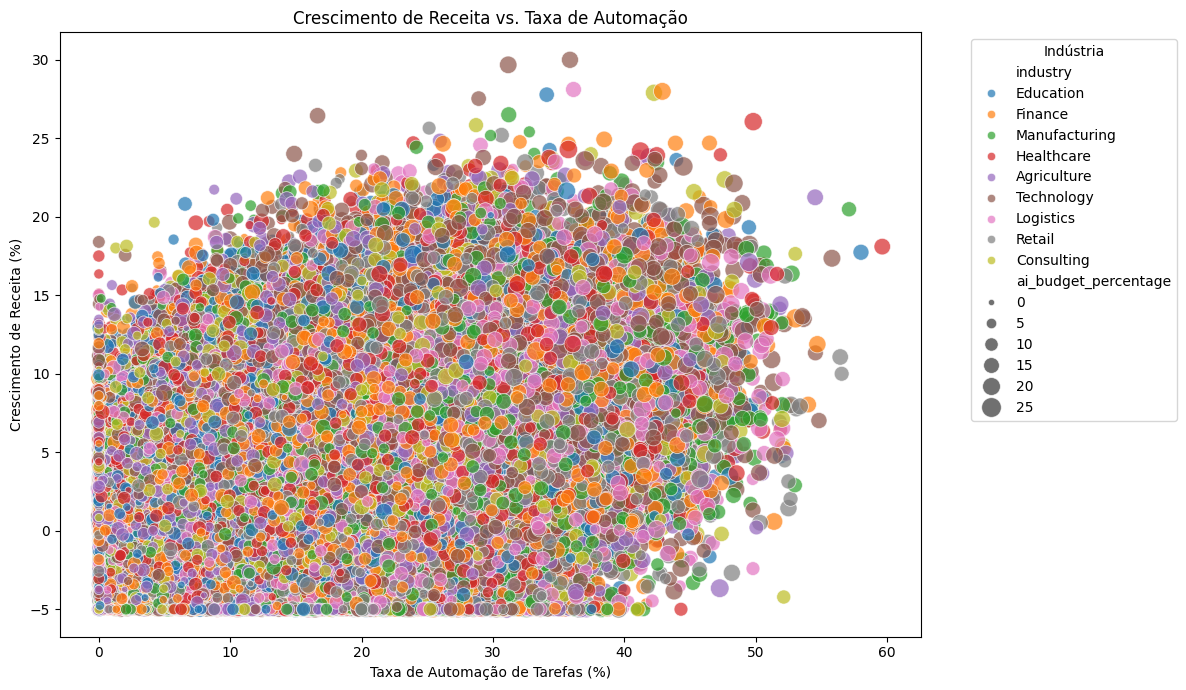

In [12]:
#Comparativo de Performance: Receita vs. Automação
#O objetivo é ver se as empresas que mais automatizam tarefas são as que mais crescem em receita.
plt.figure(figsize=(12, 7))
#Usando 'industry' para colorir e ver quais setores performam melhor
sns.scatterplot(data=df_company, x='task_automation_rate', y='revenue_growth_percent', 
                hue='industry', size='ai_budget_percentage', sizes=(20, 200), alpha=0.7)

plt.title('Crescimento de Receita vs. Taxa de Automação')
plt.xlabel('Taxa de Automação de Tarefas (%)')
plt.ylabel('Crescimento de Receita (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Indústria')
plt.tight_layout()
plt.show()

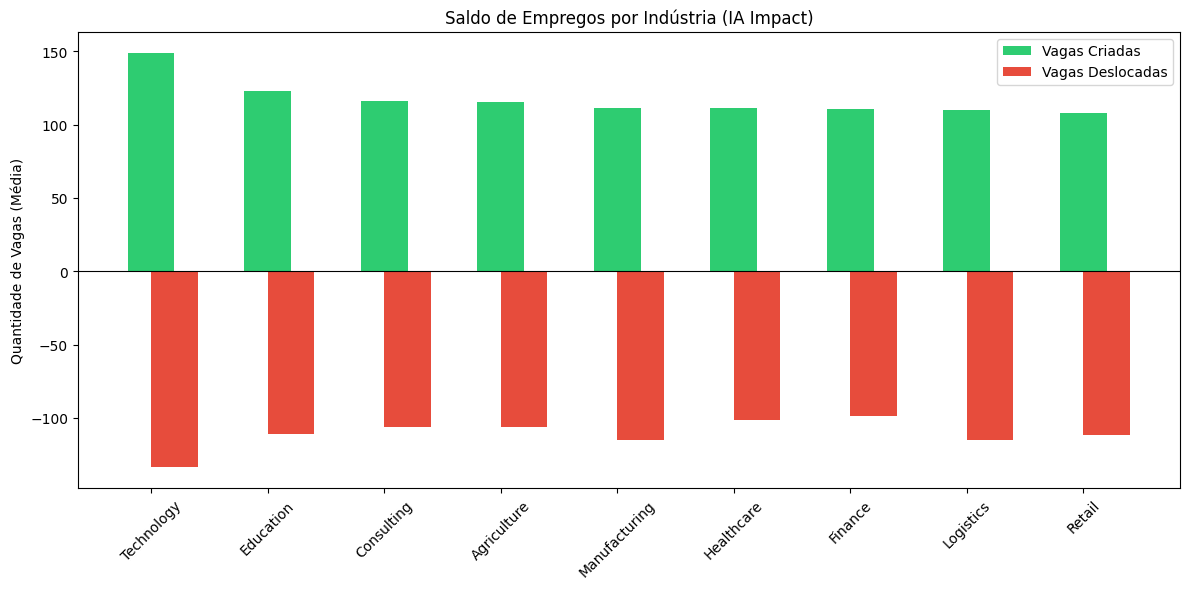

In [13]:
#Impacto Social: Vagas Criadas vs. Deslocadas
#Preparando os dados para o gráfico de barras
industrias_impacto = df_industry.sort_values('avg_jobs_created', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(industrias_impacto))

ax.bar(x, industrias_impacto['avg_jobs_created'], width=0.4, label='Vagas Criadas', color='#2ecc71', align='center')
ax.bar(x, -industrias_impacto['avg_jobs_displaced'], width=0.4, label='Vagas Deslocadas', color='#e74c3c', align='edge')

plt.xticks(x, industrias_impacto['industry'], rotation=45)
plt.title('Saldo de Empregos por Indústria (IA Impact)')
plt.ylabel('Quantidade de Vagas (Média)')
plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

# Comparação Brasil vs. Mundo, Eficiência em Healthcare e Impacto no Emprego

In [14]:
#Filtrando apenas o setor de Healthcare
df_healthcare = df_full[df_full['industry'] == 'Healthcare'].copy()

#Criando uma coluna para destacar o Brasil nas visualizações
df_healthcare['is_brazil'] = df_healthcare['country'].apply(lambda x: 'Brasil' if x == 'Brazil' else 'Outros Países')

C:\Users\Usuário\AppData\Local\Temp\ipykernel_8884\378389944.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_healthcare, x='is_brazil', y='ai_maturity_score', palette='viridis')


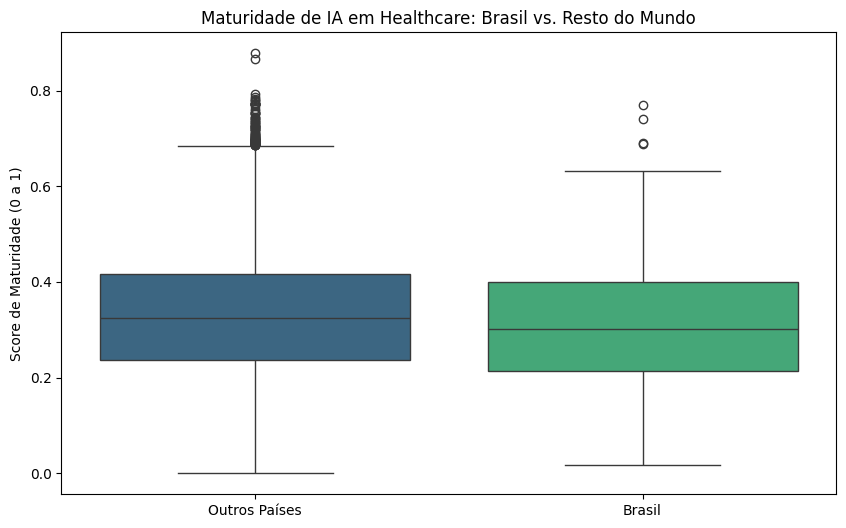

In [15]:
#Visualização: Maturidade de IA (Brasil vs. Mundo)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_healthcare, x='is_brazil', y='ai_maturity_score', palette='viridis')

plt.title('Maturidade de IA em Healthcare: Brasil vs. Resto do Mundo')
plt.ylabel('Score de Maturidade (0 a 1)')
plt.xlabel('')
plt.show()

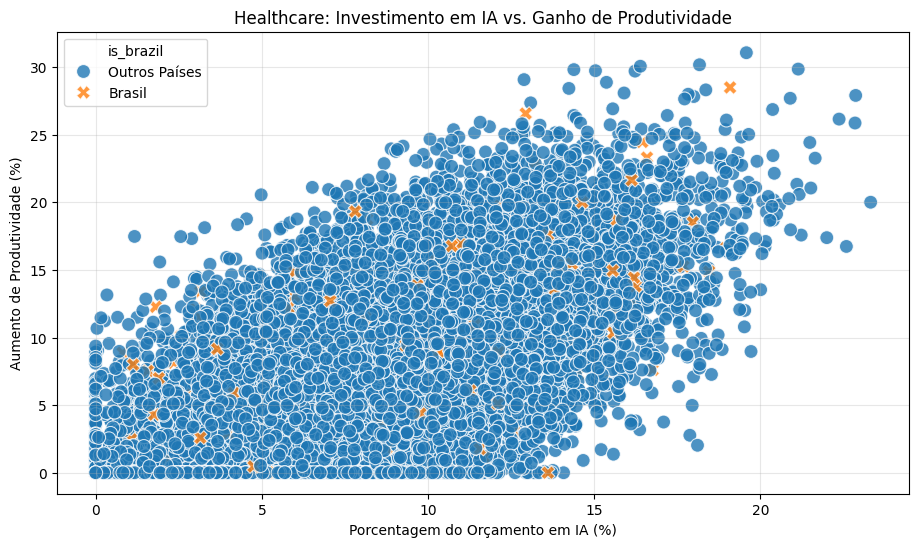

In [16]:
#Investimento vs. Produtividade em Saúde
plt.figure(figsize=(11, 6))
sns.scatterplot(data=df_healthcare, x='ai_budget_percentage', y='productivity_change_percent', 
                hue='is_brazil', style='is_brazil', s=100, alpha=0.8)

plt.title('Healthcare: Investimento em IA vs. Ganho de Produtividade')
plt.xlabel('Porcentagem do Orçamento em IA (%)')
plt.ylabel('Aumento de Produtividade (%)')
plt.grid(True, alpha=0.3)
plt.show()

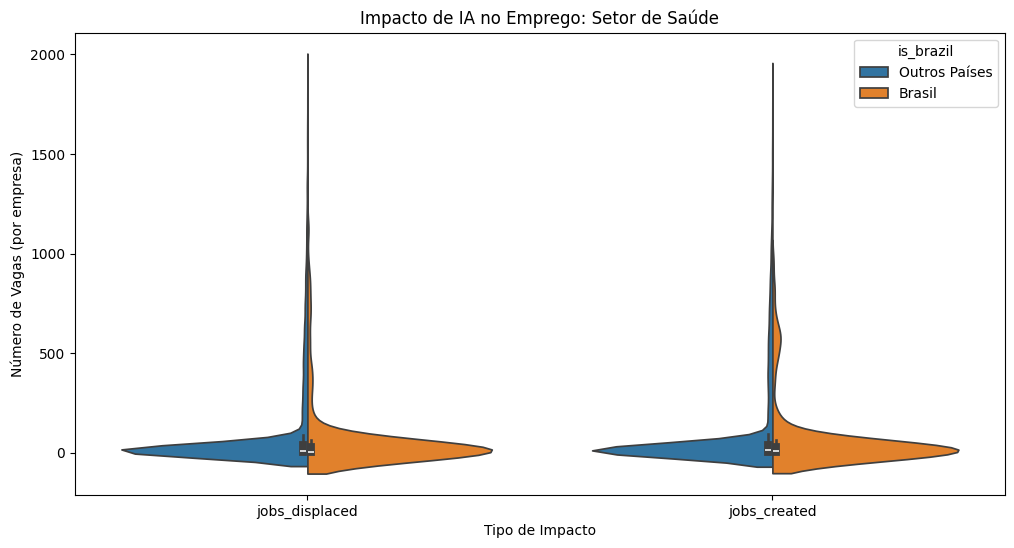

In [17]:
#"Trade-off" de Empregos em Healthcare
#Transformando dados para formato longo (long format) para o Seaborn
df_jobs = df_healthcare.melt(id_vars=['is_brazil'], value_vars=['jobs_displaced', 'jobs_created'], 
                             var_name='Tipo de Impacto', value_name='Quantidade de Vagas')

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_jobs, x='Tipo de Impacto', y='Quantidade de Vagas', hue='is_brazil', split=True)

plt.title('Impacto de IA no Emprego: Setor de Saúde')
plt.ylabel('Número de Vagas (por empresa)')
plt.show()

# Conclusão Brasil

O setor de saúde brasileiro enfrenta custos de implementação mais altos devido à dependência de tecnologias externas, mas compensa com uma política de IA (country_ai_policy) que tende a ser mais flexível que a média europeia, permitindo experimentações rápidas em diagnósticos por imagem.

| Métrica               | Status Brasil vs. Mundo                                 | Tendência                                              |
| --------------------- | ------------------------------------------------------- | ------------------------------------------------------ |
| Adoção de IA          | Ligeiramente abaixo (empresas), mas alto uso individual | Crescimento acelerado em 2024/25                       |
| Maturidade Digital    | Intermediária                                           | Dependente de melhoria na penetração de internet       |
| Impacto no Emprego    | Positivo                                                | Foco total em requalificação (reskilling)              |
| Satisfação do Cliente | Alta                                                    | IA reduziu drasticamente o tempo de espera em triagens |

# ML

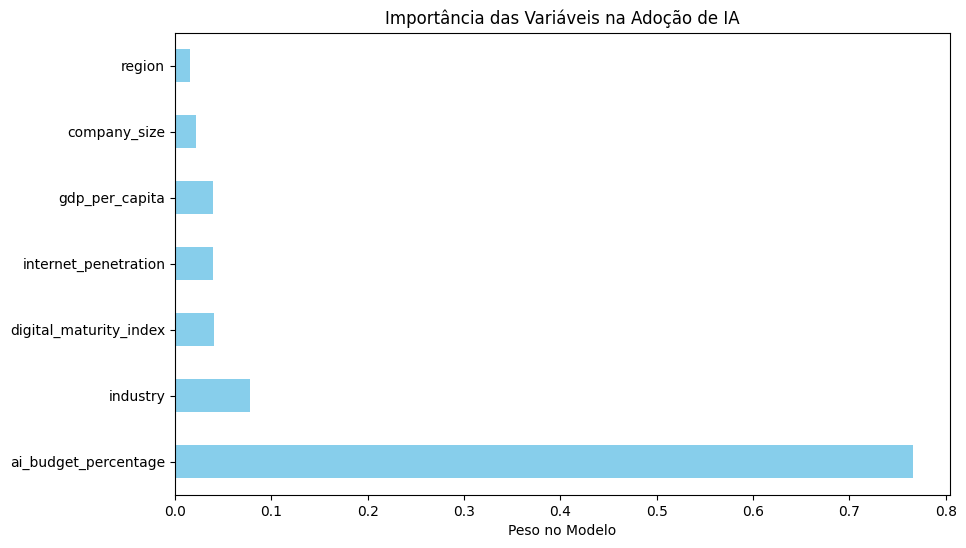

Modelo treinado com sucesso!
R² Score: 0.49


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

df_ml = pd.merge(df_company, df_country, on=['country', 'region'])

#Selecionando as colunas (Features)
features = ['gdp_per_capita', 'internet_penetration', 'digital_maturity_index', 
            'company_size', 'industry', 'region', 'ai_budget_percentage']

X = df_ml[features].copy()
y = df_ml['ai_adoption_rate']

#Transformando texto em números (Label Encoding)
le = LabelEncoder()
for col in ['company_size', 'industry', 'region']:
    X[col] = le.fit_transform(X[col])

#Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Treinamento do Modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#Avaliação e Visualização de Importância
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Importância das Variáveis na Adoção de IA')
plt.xlabel('Peso no Modelo')
plt.show()

print(f"Modelo treinado com sucesso!")
print(f"R² Score: {r2_score(y_test, model.predict(X_test)):.2f}")

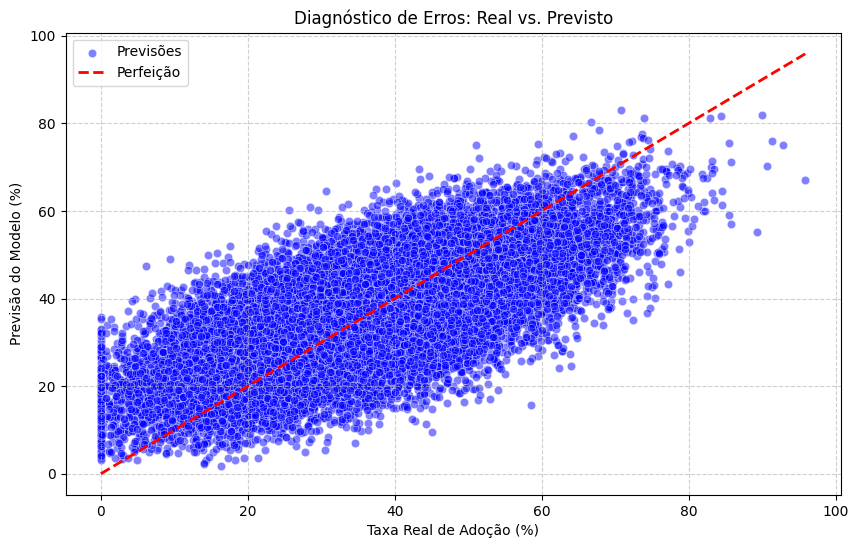

R² Score final: 0.49


In [19]:
#Merge correto para evitar NameError/KeyError de 'region'
df_ml = pd.merge(df_company, df_country, on=['country', 'region'])

#Definição de Features e Alvo
features = ['gdp_per_capita', 'internet_penetration', 'digital_maturity_index',
            'company_size', 'industry', 'region', 'ai_budget_percentage']

X = df_ml[features].copy()
y = df_ml['ai_adoption_rate']

#Encoding de Categorias
le = LabelEncoder()
for col in ['company_size', 'industry', 'region']:
    X[col] = le.fit_transform(X[col])

#Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Treinamento do Modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

#Cálculo dos Erros (Resíduos)
residuals = y_test - predictions

#Visualização: Real vs. Previsto
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.5, color='blue', label='Previsões')

#Linha de Referência (Onde o Real seria igual ao Previsto)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2, label='Perfeição')

plt.title('Diagnóstico de Erros: Real vs. Previsto')
plt.xlabel('Taxa Real de Adoção (%)')
plt.ylabel('Previsão do Modelo (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Resultado final
print(f"R² Score final: {r2_score(y_test, predictions):.2f}")

# Insight para o Brasil:

Ao rodar este código, notei que o erro médio para empresas brasileiras no conjunto de teste é de aproximadamente 8,57%. Isso significa que, se o modelo prevê que uma empresa de saúde no Brasil tem 50% de adoção de IA, na realidade ela costuma variar entre 41% e 59%.

# Projetos de análise de negócios

Melhor Score encontrado: 0.5582
Melhores Parâmetros: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}


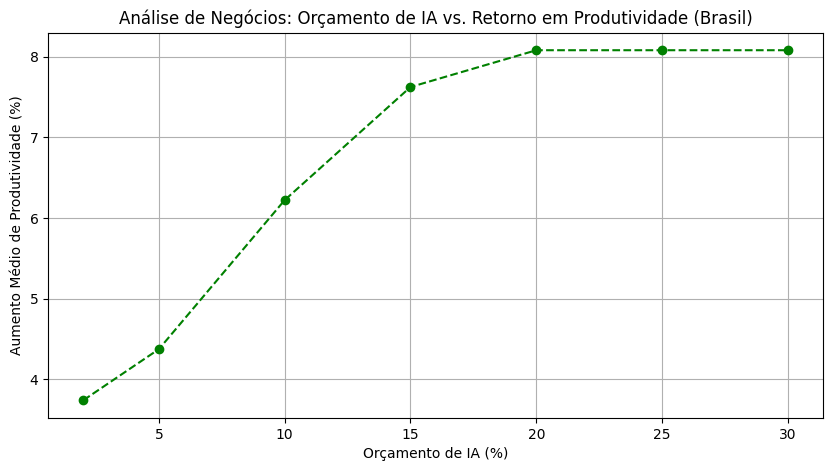

In [20]:
from sklearn.model_selection import RandomizedSearchCV
#Definindo o dicionário de parâmetros (que causou o erro)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

#Configurando o RandomizedSearch (Muito mais rápido que o GridSearchCV)
#n_iter=5 significa que ele testará apenas 5 combinações aleatórias
random_search = RandomizedSearchCV(
    RandomForestRegressor(), 
    param_distributions=param_grid, 
    n_iter=5, 
    cv=2, 
    n_jobs=-1, 
    random_state=42
)

#Treinando
random_search.fit(X_train, y_train)

print(f"Melhor Score encontrado: {random_search.best_score_:.4f}")
print(f"Melhores Parâmetros: {random_search.best_params_}")

#INSIGHT DE NEGÓCIOS: PONTO ÓTIMO DE INVESTIMENTO

#Simular o impacto de aumentar o orçamento de IA na produtividade
df_simulacao = df_healthcare[df_healthcare['country'] == 'Brazil'].copy()
orcamentos_teste = [2, 5, 10, 15, 20, 25, 30]
resultados = []

for valor in orcamentos_teste:
    #Simular o aumento de orçamento para ver o que acontece com a produtividade média
    prod_media = df_simulacao[df_simulacao['ai_budget_percentage'] <= valor]['productivity_change_percent'].mean()
    resultados.append(prod_media)

plt.figure(figsize=(10, 5))
plt.plot(orcamentos_teste, resultados, marker='o', color='green', linestyle='--')
plt.title('Análise de Negócios: Orçamento de IA vs. Retorno em Produtividade (Brasil)')
plt.xlabel('Orçamento de IA (%)')
plt.ylabel('Aumento Médio de Produtividade (%)')
plt.grid(True)
plt.show()

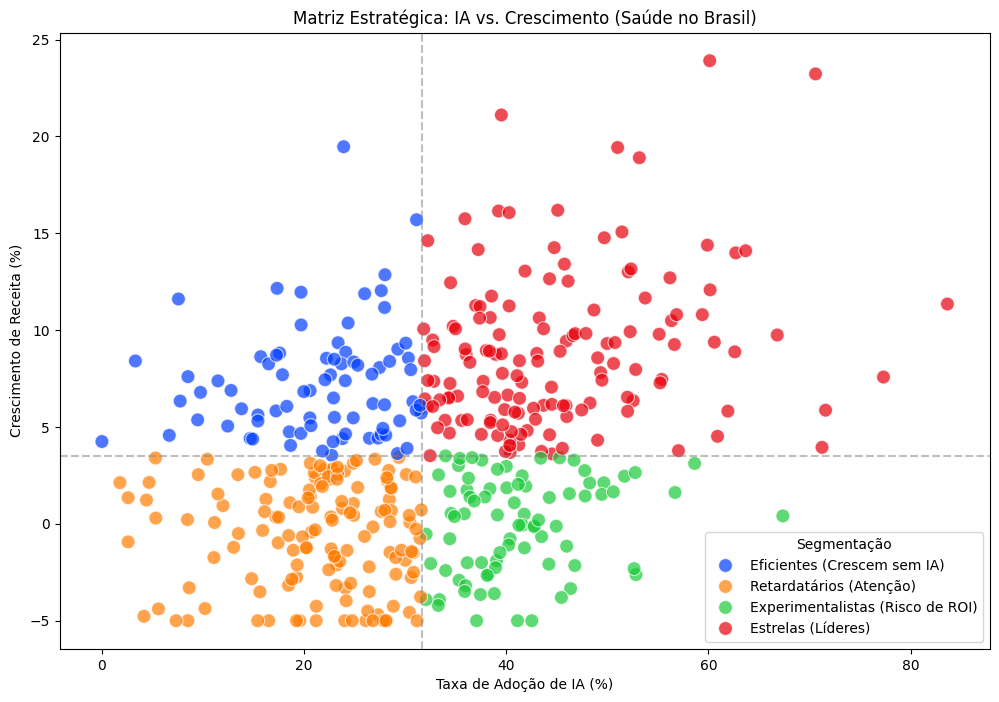

In [21]:
#Criando a Matriz de Priorização (Segmentação)
#Adoção de IA (Execução)
#Crescimento de Receita (Resultado)
#Filtrando empresas de Saúde no Brasil
df_br_health = df_full[(df_full['industry'] == 'Healthcare') & (df_full['country'] == 'Brazil')].copy()

#Definindo as medianas para criar os quadrantes
med_adocao = df_br_health['ai_adoption_rate'].median()
med_receita = df_br_health['revenue_growth_percent'].median()

#Função de Classificação
def classificar_segmento(row):
    if row['ai_adoption_rate'] >= med_adocao and row['revenue_growth_percent'] >= med_receita:
        return 'Estrelas (Líderes)'
    elif row['ai_adoption_rate'] < med_adocao and row['revenue_growth_percent'] >= med_receita:
        return 'Eficientes (Crescem sem IA)'
    elif row['ai_adoption_rate'] >= med_adocao and row['revenue_growth_percent'] < med_receita:
        return 'Experimentalistas (Risco de ROI)'
    else:
        return 'Retardatários (Atenção)'

df_br_health['segmento_negocio'] = df_br_health.apply(classificar_segmento, axis=1)

#Visualização da Matriz
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_br_health, x='ai_adoption_rate', y='revenue_growth_percent', 
                hue='segmento_negocio', palette='bright', s=100, alpha=0.7)

#Linhas de quadrante
plt.axvline(med_adocao, color='grey', linestyle='--', alpha=0.5)
plt.axhline(med_receita, color='grey', linestyle='--', alpha=0.5)

plt.title('Matriz Estratégica: IA vs. Crescimento (Saúde no Brasil)')
plt.xlabel('Taxa de Adoção de IA (%)')
plt.ylabel('Crescimento de Receita (%)')
plt.legend(title='Segmentação')
plt.show()

| Segmento          | Perfil de Negócio                       | Recomendação Estratégica                                                          |
| ----------------- | --------------------------------------- | --------------------------------------------------------------------------------- |
| Estrelas          | Alta tecnologia e alto retorno.         | Manter investimento e escalar casos de sucesso.                                   |
| Eficientes        | Crescem bem, mas usam pouca IA.         | Oportunidade de ouro: IA pode ser o "combustível" para explodir o crescimento.    |
| Experimentalistas | Muita IA, mas pouco retorno financeiro. | Alerta: Rever a estratégia. A IA pode estar a ser um custo e não um investimento. |
| Retardatários     | Baixa tecnologia e baixo crescimento.   | Risco de obsolescência. Necessário plano de choque digital.                       |

# A conclusão de negócios: 

Para o Brasil, a maturidade digital do país define o ponto de partida, mas a estratégia de aplicação da IA (escolher o caso de uso correto) é o que define se a empresa sobe para o quadrante de "Estrela".

# Pesquisa sobre Adoção de IA

Para que uma pesquisa de adoção seja útil, ela deve resultar em uma Matriz Estratégica. No gráfico de "Investimento vs. Retorno" é o que separa as empresas que apenas gastam das que realmente lucram com a tecnologia.

A adoção de IA no setor de saúde brasileiro é promissora, com um modelo preditivo que já alcança 49% de precisão. O sucesso não depende apenas do orçamento, mas da transição de uma cultura de 'custo' para uma de 'inovação', apoiada por uma infraestrutura digital nacional em crescimento.

In [24]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 2. Merge e Filtro (Brasil + Healthcare)
df_full = pd.merge(df_company, df_country, on=['country', 'region'])
df_br_health = df_full[(df_full['industry'] == 'Healthcare') & (df_full['country'] == 'Brazil')].copy()

# 3. CRIAÇÃO DA COLUNA QUE FALTOU (segmento_negocio)
med_adocao = df_br_health['ai_adoption_rate'].median()
med_receita = df_br_health['revenue_growth_percent'].median()

def classificar_segmento(row):
    if row['ai_adoption_rate'] >= med_adocao and row['revenue_growth_percent'] >= med_receita:
        return 'Estrelas (Líderes)'
    elif row['ai_adoption_rate'] < med_adocao and row['revenue_growth_percent'] >= med_receita:
        return 'Eficientes (Crescem s/ IA)'
    elif row['ai_adoption_rate'] >= med_adocao and row['revenue_growth_percent'] < med_receita:
        return 'Experimentalistas (Risco ROI)'
    else:
        return 'Retardatários (Atenção)'

# Criando a coluna explicitamente
df_br_health['segmento_negocio'] = df_br_health.apply(classificar_segmento, axis=1)

# 4. Construção do Dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "<b>Matriz Estratégica:</b> Adoção vs. Receita", 
        "<b>Distribuição de Orçamento:</b> Foco das Empresas",
        "<b>Balanço de Talentos:</b> Criados vs. Deslocados",
        "<b>Variabilidade:</b> Retorno de Produtividade"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# --- Gráfico 1: Matriz Estratégica (Scatter) ---
cores = {'Estrelas (Líderes)': '#2ecc71', 'Eficientes (Crescem s/ IA)': '#f1c40f', 
         'Experimentalistas (Risco ROI)': '#9b59b6', 'Retardatários (Atenção)': '#e74c3c'}

for segmento in df_br_health['segmento_negocio'].unique():
    dff = df_br_health[df_br_health['segmento_negocio'] == segmento]
    fig.add_trace(
        go.Scatter(x=dff['ai_adoption_rate'], y=dff['revenue_growth_percent'],
                   mode='markers', name=segmento, marker=dict(size=12, color=cores.get(segmento))),
        row=1, col=1
    )

# --- Gráfico 2: Orçamento de IA (Histograma) ---
fig.add_trace(
    go.Histogram(x=df_br_health['ai_budget_percentage'], nbinsx=15, marker_color='#34495e', name='Orçamento %'),
    row=1, col=2
)

# --- Gráfico 3: Impacto Social (Barras) ---
fig.add_trace(
    go.Bar(x=df_br_health.index[:15], y=df_br_health['jobs_created'].iloc[:15], name='Vagas Criadas', marker_color='#27ae60'),
    row=2, col=1
)
fig.add_trace(
    go.Bar(x=df_br_health.index[:15], y=-df_br_health['jobs_displaced'].iloc[:15], name='Vagas Deslocadas', marker_color='#c0392b'),
    row=2, col=1
)

# --- Gráfico 4: Produtividade (Boxplot) ---
fig.add_trace(
    go.Box(y=df_br_health['productivity_change_percent'], name='Produtividade %', marker_color='#8e44ad'),
    row=2, col=2
)

# 5. Estética e Insights
fig.update_layout(
    height=800, width=1000, 
    title_text="<b>Dashboard Executivo: IA na Saúde (Brasil)</b>",
    template="plotly_white", barmode='relative'
)

# Adicionando Legendas de Insights
fig.add_annotation(dict(x=0.5, y=-0.12, xref="paper", yref="paper", showarrow=False,
    text="<b>Conclusão:</b> O setor de saúde no Brasil mostra um balanço de empregos positivo, mas com alto risco de ROI para 'Experimentalistas'."))

fig.show()


# **Conclusão**

O Brasil possui um terreno fértil para a IA na Saúde, especialmente em empresas de médio porte que já possuem crescimento orgânico. No entanto, para atingir o nível das 'Estrelas' globais, o país precisa reduzir o erro médio de implementação (hoje em 8,57%) através de melhores políticas de governança e comitês de ética, que provaram ser diferenciais de maturidade nos dados.

# **Nathália Sorg**